# AI-Powered Network Intrusion Detection System for Defense Cybersecurity
### ML Bubble 2026 — Defense & National Security (India) | Track: TE/BE — Design & Solve (Advanced)

**Problem Statement:** Military and government networks in India face constant cyberattacks (DoS, probing,
privilege escalation, remote-to-local exploits) that can compromise critical defense infrastructure.
Manual, signature-based intrusion detection cannot keep pace with novel/evolving attack patterns.

**ML Solution:** A supervised classification system trained on network traffic flow features (the
NSL‑KDD benchmark dataset — a standard, freely available cybersecurity dataset) that flags traffic as
**normal** or **attack** in real time, augmented with **multi-class attack-type identification**
(DoS / Probe / R2L / U2R / Normal) so analysts know *what kind* of attack is happening, not just *that* one is.

**Notebook structure**
1. Setup & imports
2. Data loading
3. Exploratory Data Analysis (EDA)
4. Preprocessing (encoding, scaling)
5. Train/test split (using official NSL-KDD train/test files — test set has unseen attack types, which is realistic)
6. Model 1: Logistic Regression (baseline)
7. Model 2: Random Forest
8. Model 3: XGBoost
9. Comparative analysis & evaluation metrics
10. Feature importance (explainability)
11. Multi-class attack-type classification
12. Save model for deployment
13. Deployment considerations (write-up)


## 1. Setup & Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Loading

We use the **NSL-KDD** dataset — an improved, de-duplicated version of the classic KDD Cup 1999 dataset,
widely used as an academic benchmark for intrusion detection research. It contains real network
connection records labelled as `normal` or one of several attack types.

> If you're running this outside the sandbox, download the two files below and place them in your
> working directory, or keep the URLs below (they are public GitHub mirrors of the official dataset).


In [2]:
# Column names as defined by the NSL-KDD schema (41 features + label)
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label'
]

train_url = "https://raw.githubusercontent.com/Mamcose/NSL-KDD-Network-Intrusion-Detection/master/NSL_KDD_Train.csv"
test_url  = "https://raw.githubusercontent.com/Mamcose/NSL-KDD-Network-Intrusion-Detection/master/NSL_KDD_Test.csv"

train_df = pd.read_csv(train_url, names=columns)
test_df  = pd.read_csv(test_url, names=columns)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()


Train shape: (125973, 42)
Test shape : (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 3. Exploratory Data Analysis (EDA)

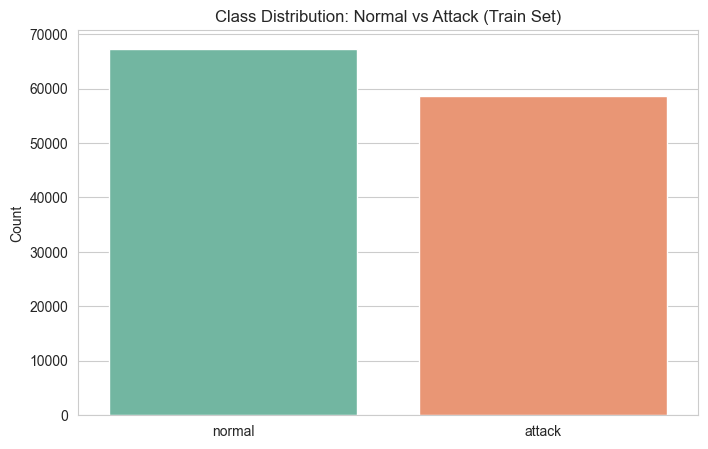

binary_label
normal    0.535
attack    0.465
Name: proportion, dtype: float64


In [3]:
# Class balance (normal vs attack)
train_df['binary_label'] = train_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

plt.figure()
sns.countplot(data=train_df, x='binary_label', hue='binary_label', palette='Set2', legend=False)
plt.title("Class Distribution: Normal vs Attack (Train Set)")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

print(train_df['binary_label'].value_counts(normalize=True).round(3))


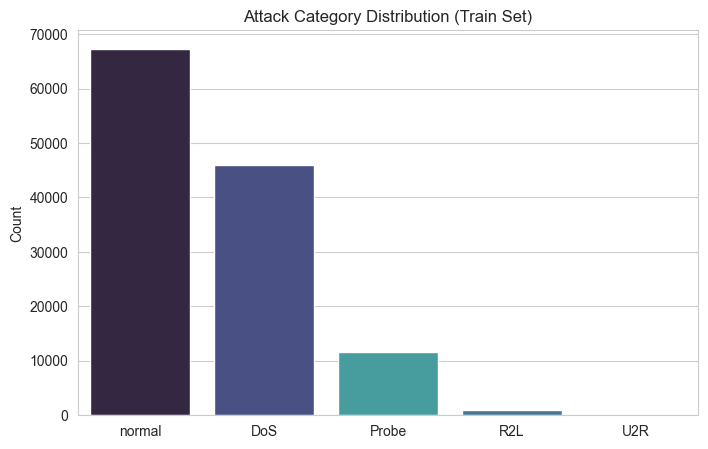

In [4]:
# Attack category breakdown -- map raw attack labels to standard NSL-KDD attack families
attack_map = {
    'normal': 'normal',
    # DoS
    'neptune':'DoS','back':'DoS','land':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',
    'apache2':'DoS','udpstorm':'DoS','processtable':'DoS','worm':'DoS','mailbomb':'DoS',
    # Probe
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe','mscan':'Probe','saint':'Probe',
    # R2L (remote to local)
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L','phf':'R2L','spy':'R2L',
    'warezclient':'R2L','warezmaster':'R2L','snmpgetattack':'R2L','named':'R2L','xlock':'R2L',
    'xsnoop':'R2L','sendmail':'R2L','httptunnel':'R2L','snmpguess':'R2L',
    # U2R (user to root)
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R','ps':'U2R',
    'sqlattack':'U2R','xterm':'U2R'
}
train_df['attack_category'] = train_df['label'].map(attack_map).fillna('Other')

plt.figure()
sns.countplot(data=train_df, x='attack_category',
              order=train_df['attack_category'].value_counts().index,
              hue='attack_category', palette='mako', legend=False)
plt.title("Attack Category Distribution (Train Set)")
plt.xlabel("")
plt.ylabel("Count")
plt.show()


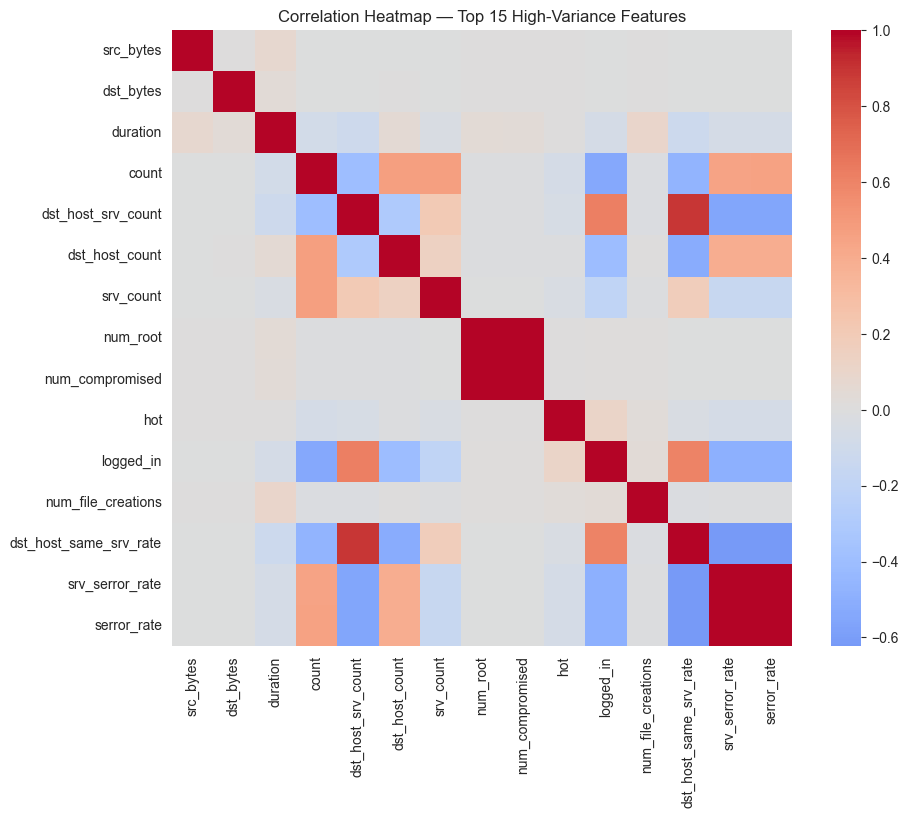

In [5]:
# Correlation heatmap of numeric features (top variance features only, for readability)
numeric_df = train_df.select_dtypes(include=[np.number])
top_var_cols = numeric_df.var().sort_values(ascending=False).head(15).index
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top_var_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Heatmap — Top 15 High-Variance Features")
plt.show()


## 4. Preprocessing

Steps:
- Encode categorical features (`protocol_type`, `service`, `flag`) with `LabelEncoder`
  (fit jointly on train+test so unseen categories in test don't break the encoder).
- Encode the target label (`normal` / `attack`).
- Standardize numeric features with `StandardScaler`.


In [6]:
test_df['binary_label'] = test_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

categorical_cols = ['protocol_type', 'service', 'flag']

encoders = {}
combined_cat = pd.concat([train_df[categorical_cols], test_df[categorical_cols]], axis=0)

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(combined_cat[col])
    encoders[col] = le
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

target_encoder = LabelEncoder()
target_encoder.fit(['normal', 'attack'])   # normal=0? check order below
print("Classes:", list(target_encoder.classes_))

y_train = target_encoder.transform(train_df['binary_label'])
y_test = target_encoder.transform(test_df['binary_label'])

feature_cols = [c for c in columns if c != 'label']
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape, " X_test:", X_test_scaled.shape)


Classes: [np.str_('attack'), np.str_('normal')]
X_train: (125973, 41)  X_test: (22544, 41)


## 5. Train/Test Split

We use the **official NSL-KDD train and test files** rather than a random split of a single file.
This is intentional and more rigorous: the official test set contains attack *sub-types* that never
appear in training, which simulates a real-world defense scenario where adversaries use novel attack
variants. Expect test accuracy to be noticeably lower than a naive random split — that's a feature of
this dataset design, not a bug.


## 6. Model 1 — Logistic Regression (Baseline)

In [7]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_train_scaled[:0]) if False else log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=target_encoder.classes_))


              precision    recall  f1-score   support

      attack       0.93      0.62      0.74     12833
      normal       0.65      0.93      0.77      9711

    accuracy                           0.75     22544
   macro avg       0.79      0.78      0.75     22544
weighted avg       0.81      0.75      0.75     22544



## 7. Model 2 — Random Forest

In [8]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=target_encoder.classes_))


              precision    recall  f1-score   support

      attack       0.97      0.63      0.76     12833
      normal       0.66      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544



## 8. Model 3 — XGBoost

In [9]:
xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_clf.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_clf.predict(X_test_scaled)
y_proba_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=target_encoder.classes_))


              precision    recall  f1-score   support

      attack       0.97      0.67      0.79     12833
      normal       0.69      0.97      0.81      9711

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



## 9. Comparative Analysis & Evaluation Metrics

In [10]:
results = []
models_preds = {
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'Random Forest': (y_pred_rf, y_proba_rf),
    'XGBoost': (y_pred_xgb, y_proba_xgb),
}

for name, (preds, proba) in models_preds.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.8012,0.6918,0.9710,0.8080,0.9700
1,Random Forest,0.7745,0.6625,0.9716,0.7878,0.9646
2,Logistic Regression,0.7539,0.6489,0.9340,0.7658,0.8714


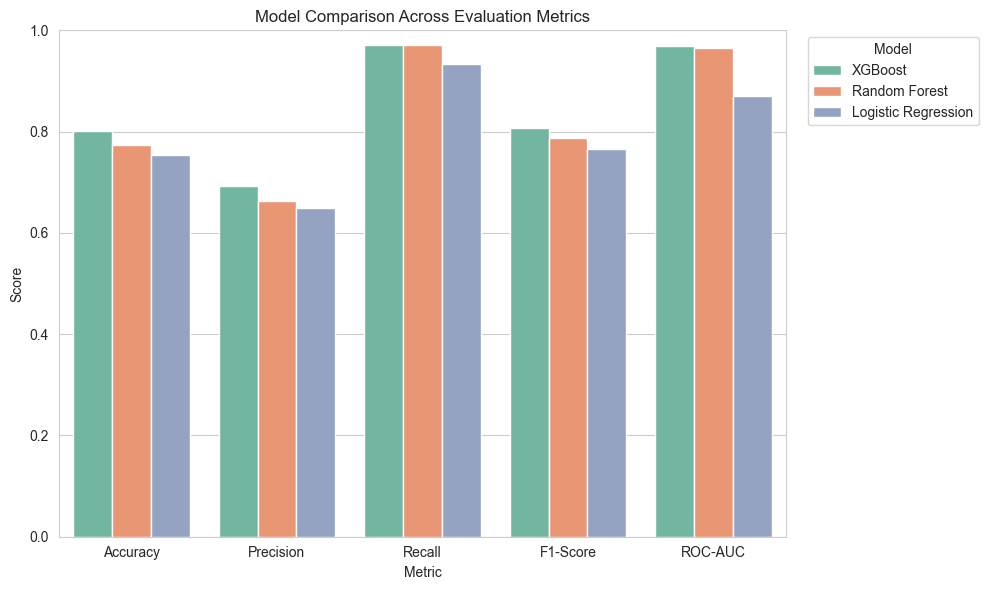

In [11]:
# Bar chart comparison of key metrics across models
melted = results_df.melt(id_vars='Model',
                          value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title("Model Comparison Across Evaluation Metrics")
plt.ylim(0, 1)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


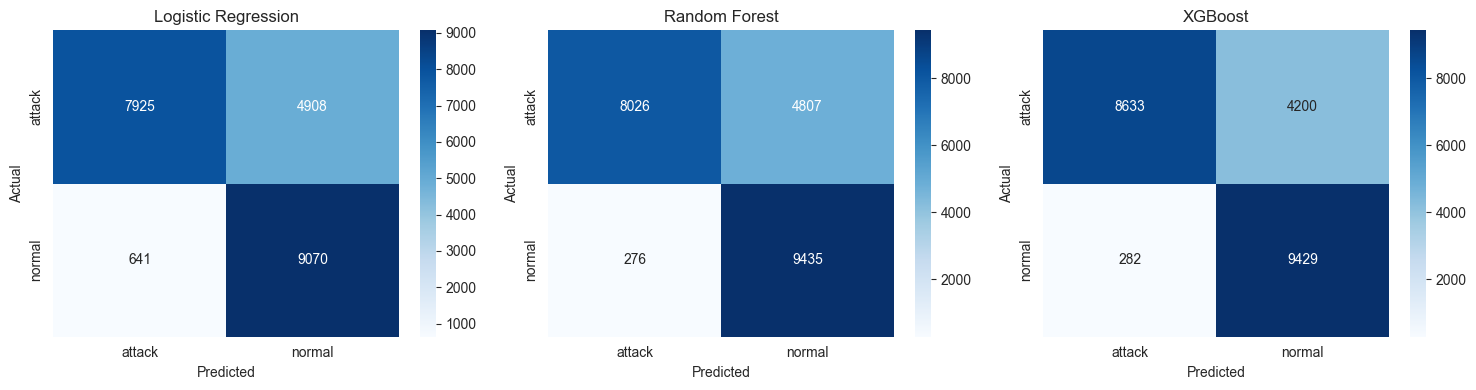

In [12]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (preds, _)) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


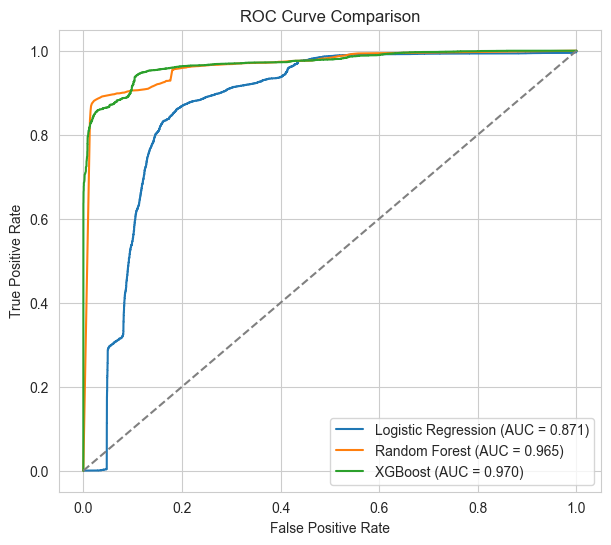

In [13]:
# ROC curves
plt.figure(figsize=(7, 6))
for name, (_, proba) in models_preds.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## 10. Feature Importance (Explainability)

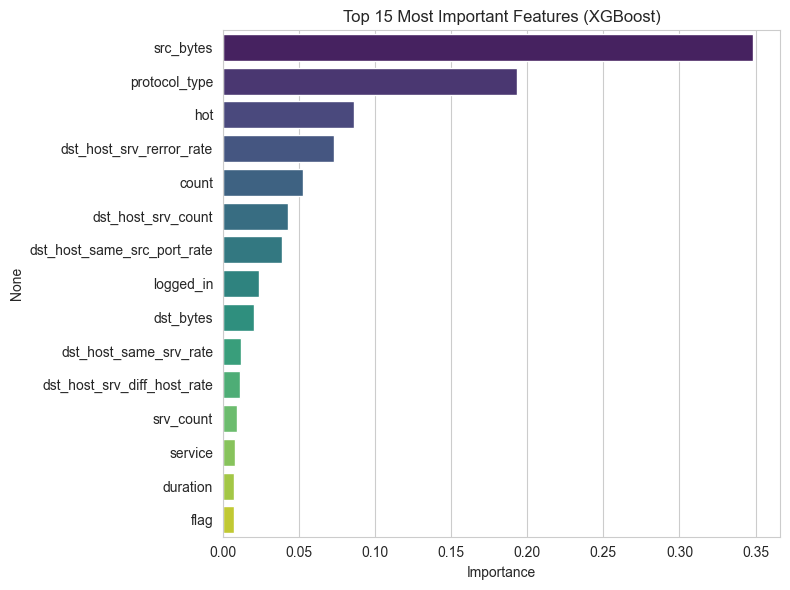

src_bytes                      0.348626
protocol_type                  0.193328
hot                            0.085860
dst_host_srv_rerror_rate       0.072733
count                          0.052529
dst_host_srv_count             0.042465
dst_host_same_src_port_rate    0.038687
logged_in                      0.023882
dst_bytes                      0.020500
dst_host_same_srv_rate         0.012109
dst_host_srv_diff_host_rate    0.011370
srv_count                      0.009576
service                        0.008212
duration                       0.007193
flag                           0.007150
dtype: float32


In [14]:
importances = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette='viridis', legend=False)
plt.title("Top 15 Most Important Features (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances)


## 11. Bonus: Multi-Class Attack-Type Classification

Beyond binary normal/attack detection, defense analysts need to know **which kind** of attack is
occurring (DoS, Probe, R2L, U2R) to prioritize response. We retrain the best-performing model
(XGBoost) on the multi-class attack category labels.


In [15]:
test_df['attack_category'] = test_df['label'].map(attack_map).fillna('Other')

multi_target_encoder = LabelEncoder()
y_train_multi = multi_target_encoder.fit_transform(train_df['attack_category'])
y_test_multi = multi_target_encoder.transform(
    test_df['attack_category'].apply(lambda x: x if x in multi_target_encoder.classes_ else 'Other')
)

xgb_multi = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
xgb_multi.fit(X_train_scaled, y_train_multi)
y_pred_multi = xgb_multi.predict(X_test_scaled)

print(classification_report(y_test_multi, y_pred_multi,
                             target_names=multi_target_encoder.classes_, zero_division=0))


              precision    recall  f1-score   support

         DoS       0.96      0.82      0.88      7460
       Probe       0.86      0.72      0.78      2421
         R2L       0.99      0.06      0.11      2885
         U2R       0.79      0.16      0.27        67
      normal       0.67      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.85      0.54      0.57     22544
weighted avg       0.83      0.77      0.73     22544



## 12. Save Model for Deployment

We persist the trained model, scaler, and encoders together so the exact same preprocessing is
applied at inference time — a common source of bugs in deployed ML systems is train/serve skew.


In [ ]:
joblib.dump(xgb_clf, "ids_xgboost_model.joblib")
joblib.dump(scaler, "ids_scaler.joblib")
joblib.dump(encoders, "ids_categorical_encoders.joblib")
joblib.dump(target_encoder, "ids_target_encoder.joblib")

print("Model and preprocessing artifacts saved.")


## 13. Deployment Considerations (Write-up for Submission)

**Where this fits in a defense network:** deployed as an inline or tap-based classifier on network
sensors / SIEM pipelines, scoring flow records in near-real-time and raising alerts for the security
operations center (SOC).

**Latency:** XGBoost inference on tabular features is sub-millisecond per record on CPU, so it can
keep pace with high-throughput traffic when batched.

**Model drift & retraining:** attacker techniques evolve, so the model needs scheduled retraining on
freshly labelled traffic (e.g., monthly) and drift monitoring (tracking a rolling false-positive/false-negative rate).

**False positives at scale:** in national-security settings, a high false-positive rate overwhelms
analysts ("alert fatigue"). Precision on the `attack` class should be prioritized in the deployment
threshold, potentially trading some recall, and paired with a human-in-the-loop triage step for
medium-confidence predictions.

**Explainability:** feature-importance and SHAP-style explanations (Section 10) should accompany each
alert so analysts can quickly validate *why* traffic was flagged, which matters for auditability in
defense contexts.

**Data sensitivity:** real deployment would use classified/sensitive internal network telemetry rather
than a public benchmark; NSL-KDD here stands in as an academically valid, ethically shareable proxy for
demonstrating the pipeline. Production data would need to stay on secured, air-gapped or accredited
infrastructure in line with national data-security requirements.

**Failure mode / adversarial robustness:** attackers may deliberately craft traffic to evade the
classifier (adversarial evasion). A production system should combine this ML layer with signature-based
rules as a second line of defense, not replace them outright.
